<a href="https://colab.research.google.com/github/shintaromori/Hello-World/blob/main/ME2025_Lec14A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

# 📘 第14回：ポートフォリオ分析演習 — 実データから投資可能集合と最適ポートフォリオを理解する

### （S&P500 の 446 銘柄データを使って、現代ポートフォリオ理論を体験）

---

## 🎯 **授業の目的**

この回では、
**S&P500 のうち 2018〜2025 の全期間でデータが揃う 446 銘柄**と
**市場ベンチマーク（S&P500 / SPY）** を使って、

* **株価データからリターン・リスク（標準偏差）を計算する**
* **銘柄間の相関構造を理解する**
* **ランダムにポートフォリオを作り、投資可能集合（feasible set）を描く**
* **最小分散ポートフォリオ（Minimum-Variance Portfolio）を求める**

という、ポートフォリオ理論の中心部分を実データで可視化します。

第13回で学んだ「リスクとリターン」の考え方を、
**多銘柄ポートフォリオに拡張する回**です。

---

## 📂 **データソース：Github（本講義専用リポジトリ）**

使用する株価データ（446銘柄）は以下にアップロード済みです：

🔗 **[https://github.com/CS-Advanced/DATA](https://github.com/CS-Advanced/DATA)**

Notebook では、この CSV を直接読み込みます。
さらに、ベンチマークとして **S&P500 ETF（SPY）** を yfinance から取得しています。

---

## 🔍 **Step 1：日次リターンの計算と基本統計量の確認**

最初のコードセルで読み込んだ株価データから、
**日次リターン（%変化率）** を計算します。

調べる内容：

* 各銘柄の

  * 平均リターン
  * 標準偏差（ボラティリティ）
* S&P500（市場）のリスクとリターン

ポイント：

* リスク・リターンは銘柄ごとに大きく異なる

このステップで、金融データの「癖」を把握します。

---


## 📊 **Step 2：ランダムポートフォリオによる投資可能集合の“サンプル”を可視化する**

446 銘柄からランダムに重みベクトル (w) を生成し、

[
\text{Return} = w^\top \mu, \qquad
\text{Risk} = \sqrt{w^\top \Sigma w}
]

を計算して **リスク × リターン平面に散布図としてプロット**します。

ここで得られる点は、
**理論的な投資可能集合（Feasible Set）からランダムにサンプリングした一部の点**です。

> 🔍 *446銘柄のような高次元では、
> ランダムサンプリングでは投資可能集合のごく一部しか打てない点に注意。
> 特に境界線（効率的フロンティア）はほとんど現れません。*

---

いいね、そのStep4は「効率的フロンティアまで求める」問題にした方が断然おいしいです。
今の文をその方針に合わせて書き換えた版を出します。

---

## ⚙️ **Step 3：ターゲットリターンごとのリスク最小化による効率的フロンティア**

最後に、
**ターゲットとなる期待リターンをいくつか設定し、そのリターンを達成できるポートフォリオの中でリスクが最小になる組み合わせ**を求めます。

これをターゲットリターンの値を少しずつ変えながら繰り返すことで、
**効率的フロンティア（Efficient Frontier）** をリスク–リターン平面上に描きます。

分散が最も小さいポートフォリオが「最小分散ポートフォリオ（Global Minimum-Variance PF）」です。
ターゲットリターンを変えながら最小分散問題を解いていくと、
解の中で「分散が最小の点」が GMV に対応し、それを含む上側の曲線が効率的フロンティアになります。

---

### 🔧 最適化問題（ターゲットリターン (R_{\text{target}}) ごと）

共分散行列を (\Sigma)、年率期待リターンベクトルを (\mu) とすると、

$$
\begin{aligned}
&\min_{w} && w^\top \Sigma w \
&\text{subject to}
&& \sum_i w_i = 1 \quad (\text{全額投資}) \
&&& w_i \ge 0 \quad (\text{空売りなし}) \
&&& w^\top \mu = R_{\text{target}} \quad (\text{目標リターン条件})
\end{aligned}
$$

となります。

`scipy.optimize.minimize` を用いて、
複数の $R_{\text{target}}$ に対してこの問題を解き、
得られた ($\text{Risk}, \text{Return}$) の組を結ぶことで効率的フロンティアを描きます。

---

### ✔ この Step で得られるもの

* ターゲットリターンごとの **「最小リスクのポートフォリオ」の重み**
* それらを結んだ **効率的フロンティアの曲線**
* フロンティアの左端としての **最小分散ポートフォリオ（Global Min-Variance PF）**
* 市場ポートフォリオ（S&P500）との位置関係
  → **「市場PFがどの程度効率的か」を評価できる**

ここで、
**「投資可能集合の中で、これ以上は改善できない境界」＝効率的フロンティア**
が理論通りに現れることを確認し、Markowitz モデルの核心を体験します。



---


---


## 📝 **レポート課題**

Notebook の最後の課題に回答して下さい。

---

## 🚀 **この授業で身につくスキル**

* 多銘柄株価データの扱い方
* リターン・ボラティリティ・相関の計算
* ポートフォリオのリスク計算（共分散行列）
* 投資可能集合の可視化
* 最小分散ポートフォリオの最適化
* 市場ポートフォリオとの比較による理解

---



In [2]:
# =========================
# Setup (1st Cell)
# 必要ライブラリの導入とユーティリティ関数（以後は追加の import なし）
# =========================

# ---- オプション: 日本語フォント（未インストールなら導入）----
import importlib.util
if importlib.util.find_spec("japanize_matplotlib") is None:
    # Colab で日本語ラベルを使いたい場合のみ有効化
    !pip install -q japanize-matplotlib

# ---- 可視化 ----
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import japanize_matplotlib  # 日本語ラベルを使う場合に有効

# ---- 基本ライブラリ ----
import os, random, math
import numpy as np
import pandas as pd
from google.colab import files
from IPython.display import display

# ---- 金融データ取得 ----
import yfinance as yf

# ---- 表示設定 & 乱数固定 ----
plt.rcParams["figure.dpi"] = 150      # 図をクッキリ表示
plt.rcParams["figure.figsize"] = (4, 3)
np.random.seed(42)
random.seed(42)

# =========================
# データの取得：株価 (S&Pの446銘柄 & S&P500)
# =========================

url = "https://raw.githubusercontent.com/CS-Advanced/DATA/refs/heads/main/S%26P_446_20180102_20250829.csv"
df = pd.read_csv(url)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# S&P500 ETF (SPY) をベンチマークとして取得
spy = yf.download(
    "SPY",
    start="2018-01-01",
    end="2025-08-30",
    auto_adjust=True,
    progress=False,
)["Close"]
spy.name = "SP500"

# 日付を df に合わせて再インデックス（念のため）
spy = spy.reindex(df.index)

# 列として追加
df["SP500"] = spy

# 確認
display(df.head())

# 欠損値チェック
print("欠損値の総数:", df.isna().sum().sum())

#
print(df.shape)


,A,AAL,AAP,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,...,XEL,XOM,XRAY,XYL,YUM,ZBRA,ZBH,ZION,ZTS,SP500
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,67.599998,52.990002,106.089996,43.064999,98.410004,58.790001,29.433332,153.839996,177.699997,90.279999,...,47.810001,85.029999,67.139999,68.070000,81.599998,103.709999,120.446602,50.700001,71.769997,237.909164
2018-01-03,69.320000,52.340000,107.050003,43.057499,99.949997,58.919998,29.459999,154.550003,181.039993,91.400002,...,47.490002,86.699997,66.910004,68.900002,81.529999,105.769997,121.281555,50.639999,72.099998,239.413986
2018-01-04,68.800003,52.669998,111.000000,43.257500,99.379997,58.820000,29.570000,156.380005,183.220001,91.300003,...,47.119999,86.820000,66.900002,69.360001,82.360001,107.860001,121.106796,50.849998,72.529999,240.423111
2018-01-05,69.900002,52.650002,112.180000,43.750000,101.110001,58.990002,29.453333,157.669998,185.339996,91.669998,...,46.790001,86.750000,67.839996,69.230003,82.839996,109.540001,122.310677,50.869999,73.360001,242.025253
2018-01-08,70.050003,52.130001,111.389999,43.587502,99.489998,58.820000,29.456667,158.929993,185.039993,91.830002,...,47.139999,87.139999,68.300003,69.480003,82.980003,110.629997,122.543686,50.619999,74.239998,242.467880


欠損値の総数: 0
(1926, 447)



---

# 📘 **Step 1**

ここでは、最初のセルで読み込んだ株価データから **日次リターン（％変化率）** を求め、
次の分析を行います：

1. **各銘柄の平均リターン（年率換算）とリスク（標準偏差・年率）を計算**
2. **446銘柄のリスク–リターン散布図を作成**
3. **市場ポートフォリオ（S&P500：SPY）を同じ平面上にプロットし比較**

これにより、
「個別銘柄のリスクと市場全体の位置関係」
「分散投資の必要性」
が視覚的に理解できます。

---

# ✨ **Step 1-1：日次リターンの計算**

```python
# 日次リターン（pct_change）
returns = df.pct_change().dropna()

# 年率換算の設定
trading_days = 252  # 米国市場の年間営業日数の慣習値
```

---

# ✨ **Step 1-2：平均リターン（年率）とリスク（年率標準偏差）の計算**

```python
# 平均日次リターン → 年率換算
mean_returns = returns.mean() * trading_days

# 日次標準偏差 → 年率換算
risk_returns = returns.std() * np.sqrt(trading_days)

# 446銘柄＋SP500 のまとめ表
summary = pd.DataFrame({
    "Annual Return": mean_returns,
    "Annual Risk (Std)": risk_returns
})

display(summary.head())
```

---

# ✨ **Step 1-3：リスク–リターン散布図の作成
```python
plt.figure(figsize=(6,4))

# 446銘柄（SP500列以外）
mask = summary.index != "SP500"
plt.scatter(
    summary.loc[mask, "Annual Risk (Std)"],
    summary.loc[mask, "Annual Return"],
    s=10, alpha=0.5, label="Individual Stocks (446)"
)

# S&P500（市場ポートフォリオ）
plt.scatter(
    summary.loc["SP500", "Annual Risk (Std)"],
    summary.loc["SP500", "Annual Return"],
    color="red", s=50, marker="x", label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Risk–Return Map: 446 Stocks vs S&P500")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
```

---

# 📊 **Step 1 のポイント（模範的な解釈）**

ここでは、散布図から読み取れる典型的な特徴を整理します。

---

## 🟦 **（1）446銘柄の多くは「左下～右下」に広く散布している**

* リスク（標準偏差）は銘柄により大きく異なる
  → 約10%〜40%程度までばらつく
* リターンもプラス・マイナスで分布

個別銘柄の動きはバラバラで、
**市場全体より高リスク・低リターンの銘柄が多数存在**することがわかる。

---

## 🟥 **（2）S&P500（市場ポートフォリオ）の位置が特徴的**

赤い×印で示した S&P500（SPY）は、

* **リスクが中程度（他銘柄の中心付近）**
* **リターンは個別銘柄より高めに出ることが多い**

→ 個別銘柄の単純平均ではなく **時価総額加重平均** のため、
　強い銘柄（Apple、Microsoft など）の寄与が大きい。

---

## 🟩 **（3）市場ポートフォリオは"効率的"に見える**

散布図を見ると：

* S&P500 は **点群より左上側（＝効率的側）** に位置することが多い
* つまり、
  **同じリスクの個別銘柄より高いリターンを出している場合が多い**

これは Markowitz の
「分散投資がリスクを低減し、結果的に効率的ポートフォリオになる」
という理論的結果と一致する。

---

## 🟨 **（4）なぜ市場ポートフォリオは効率的なのか？**

* 446銘柄の中から、時価総額に応じて適度に分散されている
* 特定の企業のリスク（固有リスク）が平均化される
* 市場全体の動き（市場リスク）だけが残り、**総リスクが低下**

つまり、
**市場（S&P500）を買う行為は、自然な分散投資になっている**
という事実が可視化される。

---

## 📝 **Step1 のまとめ**

* 個別株はばらつきが大きく、高リスクのものも多い
* S&P500 は適度に分散されており、
  **同じリスクならより高いリターンを実現できる位置にある**
* この結果は、**「分散投資は合理的である」**ことを実証的に裏付ける

---


In [5]:
# 日次リターン（pct_change）
returns = df.pct_change().dropna()

# 年率換算の設定
trading_days = 252  # 米国市場の年間営業日数の慣習値

# 平均日次リターン → 年率換算
mean_returns = returns.mean() * trading_days

# 日次標準偏差 → 年率換算
risk_returns = returns.std() * np.sqrt(trading_days)

# 446銘柄＋SP500 のまとめ表
summary = pd.DataFrame({
    "Annual Return": mean_returns,
    "Annual Risk (Std)": risk_returns
})

display(summary.head())

,Annual Return,Annual Risk (Std)
A,0.123548,0.290839
AAL,-0.022300,0.568356
AAP,0.030483,0.458097
AAPL,0.269105,0.311669
ABBV,0.136143,0.269074


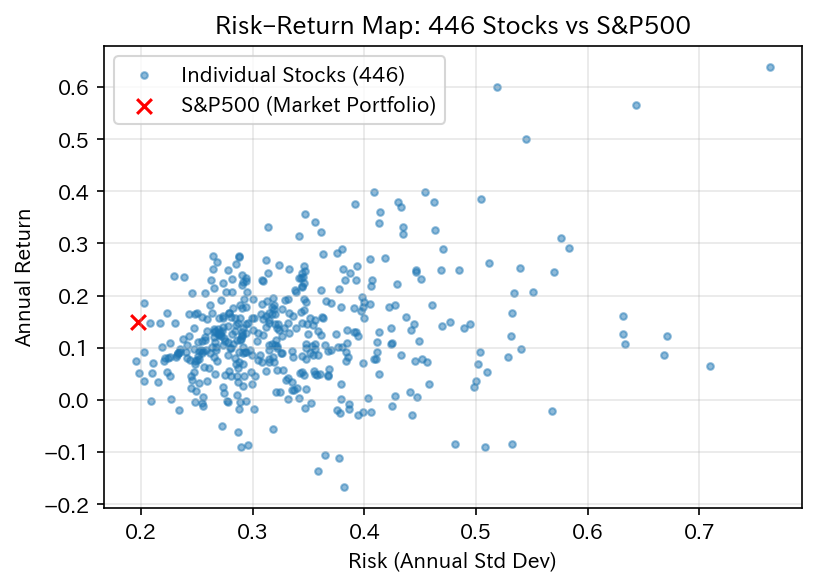

In [6]:
plt.figure(figsize=(6,4))

# 446銘柄（SP500列以外）
mask = summary.index != "SP500"
plt.scatter(
    summary.loc[mask, "Annual Risk (Std)"],
    summary.loc[mask, "Annual Return"],
    s=10, alpha=0.5, label="Individual Stocks (446)"
)

# S&P500（市場ポートフォリオ）
plt.scatter(
    summary.loc["SP500", "Annual Risk (Std)"],
    summary.loc["SP500", "Annual Return"],
    color="red", s=50, marker="x", label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Risk–Return Map: 446 Stocks vs S&P500")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



---

# 📊 **Step 2:ランダムポートフォリオによる投資可能集合の“サンプル”を可視化する**

446 銘柄からランダムに重みベクトル (w) を生成し、

$$
\text{Return} = w^\top \mu, \qquad
\text{Risk} = \sqrt{w^\top \Sigma w}
$$

を計算して、リスク × リターン平面上に散布図として可視化します。

ここでプロットされる点は、
**理論上の投資可能集合（Feasible Set）をランダムにサンプリングした一部の点**
にすぎません。

> 🔍 **注意（高次元の特徴）**
> 446銘柄という高次元では、ランダムサンプリングでは
> **投資可能集合のごく一部しか打てません**。
> 特に、理論で重要な **左側の境界（効率的フロンティア）** には
> ランダムではほとんど到達しません。
> → だから **Step 4 の最適化が必須** になります。

---

## ✨ **Step 2-1：ランダムポートフォリオの生成**

```python
# =========================
# Step 2：ランダムポートフォリオの生成
# =========================

# 対象銘柄（SP500列を除く）
asset_cols = [c for c in returns.columns if c != "SP500"]
n_assets = len(asset_cols)

# 共分散（個別株のみの日次データ）
cov_daily = returns[asset_cols].cov()

# 年率期待リターン（Step2で計算済み）
mean_annual = mean_returns[asset_cols]

# サンプリングするポートフォリオ数
n_portfolios = 5000

port_returns = []
port_risks = []

for _ in range(n_portfolios):
    # ランダムな重み（0〜1）、合計1に正規化
    w = np.random.random(n_assets)
    w /= w.sum()
    
    # 年率リターン
    ret = np.dot(w, mean_annual.values)
    
    # 年率リスク
    vol = np.sqrt(w @ cov_daily.values @ w * trading_days)
    
    port_returns.append(ret)
    port_risks.append(vol)

# DataFrame 化
portfolios = pd.DataFrame({
    "Annual Return": port_returns,
    "Annual Risk": port_risks
})

display(portfolios.head())
```

---

## ✨ **Step 2-2：ランダムポートフォリオと S&P500 の散布図**

```python
plt.figure(figsize=(6,4))

# ランダムポートフォリオの点
plt.scatter(
    portfolios["Annual Risk"],
    portfolios["Annual Return"],
    s=5, alpha=0.35, label="Random Portfolios (sample)"
)

# 市場ポートフォリオ（S&P500）
plt.scatter(
    risk_returns["SP500"],
    mean_returns["SP500"],
    marker="x", s=60, linewidths=2, color="red",
    label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Sampled Feasible Set: 446-stock Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
```

---

# 🧭 **Step 2 の模範解釈**

---

## 🟦（1）点群は「曲線」ではなく「面」に広がる

（高次元ポートフォリオの基本形）

2銘柄では投資可能集合は**双曲線**の形になりますが、
446銘柄では組み合わせが膨大で、

* リスク–リターン平面上では **雲のような“面”状**
* 下に凸の境界はあるが、ランダム点ではほぼ見えない

という高次元特有の構造を持ちます。

---

## 🟥（2）S&P500（市場ポートフォリオ）は点群の“左上側”に位置することが多い

つまり：

* **同じリスクならより高いリターンを提供する**
* **同じリターンならより低いリスクで実現している**

→ 市場ポートフォリオは
　**単なる平均ではなく、自然な分散投資の結果として効率的側にある**。

---

## 🟩（3）ランダムでは、効率的フロンティア（最小分散境界）は現れない

446銘柄では、
ランダムに重みを振っても **左端の境界（最小分散フロンティア付近）にはほぼ到達しません。**

したがって：

> **“効率的フロンティアを描きたいなら、最適化が必要”
> → Step 4 の役割につながる。**

---

## 🟨（4）ランダムサンプルは「形を眺める」ためのもの

* 点群の広がりが「投資可能集合が面である」ことを示す
* S&P500 の位置関係から分散投資の威力を理解できる
* しかし、境界は出ないので
  → **本当に重要な曲線は Step 4 で求める**

という位置づけになります。

---

# 📝 **Step 3 のまとめ**

* ランダムポートフォリオは **投資可能集合の“雰囲気”を理解する手法**
* 446銘柄ではランダムでは境界に届かない
  → **だから最適化が必要（Step 4）**
* 市場ポートフォリオ（S&P500）は点群より効率的側にあり、
  **自然に“良いポートフォリオ”になっている**

---


In [7]:
# =========================
# Step 2：ランダムポートフォリオの生成
# =========================

# 対象銘柄（SP500列を除く）
asset_cols = [c for c in returns.columns if c != "SP500"]
n_assets = len(asset_cols)

# 共分散（個別株のみの日次データ）
cov_daily = returns[asset_cols].cov()

# 年率期待リターン（Step2で計算済み）
mean_annual = mean_returns[asset_cols]

# サンプリングするポートフォリオ数
n_portfolios = 5000

port_returns = []
port_risks = []

for _ in range(n_portfolios):
    # ランダムな重み（0〜1）、合計1に正規化
    w = np.random.random(n_assets)
    w /= w.sum()

    # 年率リターン
    ret = np.dot(w, mean_annual.values)

    # 年率リスク
    vol = np.sqrt(w @ cov_daily.values @ w * trading_days)

    port_returns.append(ret)
    port_risks.append(vol)

# DataFrame 化
portfolios = pd.DataFrame({
    "Annual Return": port_returns,
    "Annual Risk": port_risks
})

display(portfolios.head())

,Annual Return,Annual Risk
0,0.130701,0.205483
1,0.126872,0.199162
2,0.128159,0.205079
3,0.123083,0.205829
4,0.127730,0.203253


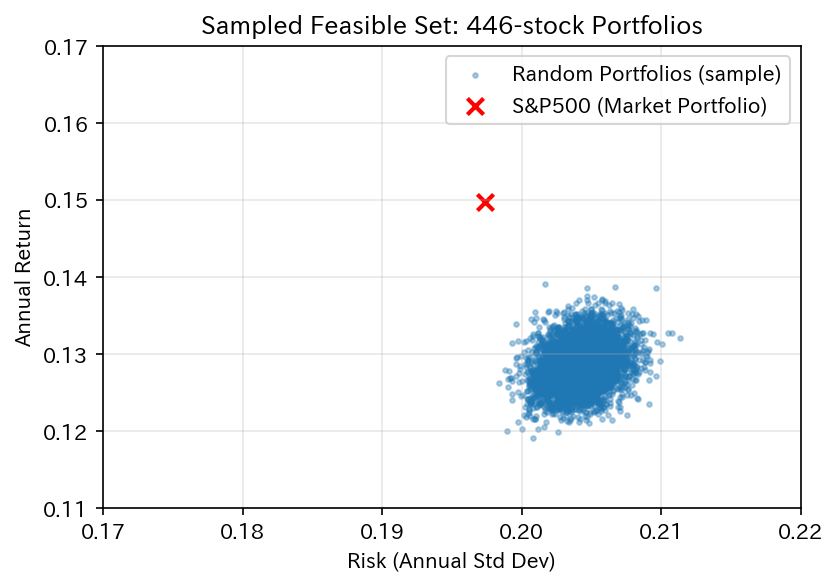

In [12]:
plt.figure(figsize=(6,4))

# ランダムポートフォリオの点
plt.scatter(
    portfolios["Annual Risk"],
    portfolios["Annual Return"],
    s=5, alpha=0.35, label="Random Portfolios (sample)"
)

# 市場ポートフォリオ（S&P500）
plt.scatter(
    risk_returns["SP500"],
    mean_returns["SP500"],
    marker="x", s=60, linewidths=2, color="red",
    label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Sampled Feasible Set: 446-stock Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0.17,0.22)
plt.ylim(0.11,0.17)
plt.show()



---

## ⚙️ **Step 3：ターゲットリターンごとのリスク最小化による効率的フロンティア**

Step 2 では、ランダムに重みを振って
**投資可能集合の“雰囲気”** を見ました。

しかし 446 銘柄という高次元では、ランダムサンプリングだけでは

* 投資可能集合のごく一部しか打てない
* 特に **左側の境界（効率的フロンティア）** にはほとんど到達しない

という限界があります。

そこで Step 3 では、

> **ターゲットとなる期待リターン (R_{\text{target}}) をいくつか設定し，
> そのリターンを達成できるポートフォリオの中で分散が最小になる重み (w) を求める**

という最適化を繰り返して、
**効率的フロンティア（Efficient Frontier）** を描きます。

同時に、**分散が最も小さいポートフォリオ**
＝ **最小分散ポートフォリオ（Global Minimum-Variance Portfolio, GMV）** も求めます。

---

### 🧮 **最適化問題の定式化**

* 共分散行列：(\Sigma)（年率ベース）
* 期待リターンベクトル：(\mu)（年率）

#### ✅ 最小分散ポートフォリオ（GMV）

まず、ターゲットリターン条件なしで

$$
\min_{w} ; w^\top \Sigma w
\quad
\text{subject to } \sum_i w_i = 1,; w_i \ge 0
$$

を解きます。
この解が **分散が最も小さいポートフォリオ（GMV）** です。

---

#### ✅ ターゲットリターン付きの最小分散問題

次に、いくつかのターゲットリターン $R_{\text{target}}$ を決めて、

$$
\begin{aligned}
&\min_{w} && w^\top \Sigma w \
&\text{subject to}
&& \sum_i w_i = 1 \quad (\text{全額投資})\
&&& w_i \ge 0 \quad (\text{空売りなし})\
&&& w^\top \mu = R_{\text{target}} \quad (\text{期待リターン条件})
\end{aligned}
$$

をターゲットごとに解きます。
得られた点 ((\text{Risk}, \text{Return})) を結んだ曲線が **効率的フロンティア** です。

> 💡 GMV は **「分散が最小の点」** として定義され、
> ターゲット付き最適化で得られた解の中でも **最も分散の小さい点が GMV に対応** します。

---

## ✨ **Step 3-1：GMV（最小分散ポートフォリオ）を求める**

```python
from scipy.optimize import minimize

# 対象銘柄（SP500 を除く）
asset_cols = [c for c in returns.columns if c != "SP500"]
n_assets = len(asset_cols)

# 年率共分散行列（個別株のみ）
cov_annual = returns[asset_cols].cov() * trading_days

# 年率期待リターンベクトル（個別株のみ）
mu_annual = mean_returns[asset_cols].values

# 目的関数：年率分散
def portfolio_variance(w, cov):
    return w @ cov @ w

# 制約：全額投資（∑w = 1）
cons_sum = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

# 空売り禁止：0 ≤ w ≤ 1
bounds = tuple((0.0, 1.0) for _ in range(n_assets))

# 初期値：均等重み
w0 = np.ones(n_assets) / n_assets

# ---- GMV（ターゲットリターン条件なし）----
res_gmv = minimize(
    portfolio_variance, w0,
    args=(cov_annual,),
    method="SLSQP",
    bounds=bounds,
    constraints=(cons_sum,)
)

w_gmv = res_gmv.x
var_gmv = portfolio_variance(w_gmv, cov_annual)
risk_gmv = np.sqrt(var_gmv)
ret_gmv  = np.dot(w_gmv, mu_annual)

print("=== Global Minimum-Variance PF (GMV) ===")
print("最小分散PFの最適化成功:", res_gmv.success)
print("Annual Risk   :", risk_gmv)
print("Annual Return :", ret_gmv)
```

---

## ✨ **Step 3-2：ターゲットリターンごとの効率的フロンティア**

```python
# GMV より少し高いリターン〜高リターンまでをターゲットにする
ret_low  = ret_gmv
ret_high = np.quantile(mu_annual, 0.9)  # 高すぎるターゲットは避ける
n_targets = 20

target_returns = np.linspace(ret_low, ret_high, n_targets)

ef_risks = []
ef_returns = []
ef_weights = []

for target in target_returns:
    # 期待リターン = target の制約
    cons_ret = {
        "type": "eq",
        "fun": lambda w, t=target: np.dot(w, mu_annual) - t
    }
    cons = (cons_sum, cons_ret)
    
    res = minimize(
        portfolio_variance, w0,
        args=(cov_annual,),
        method="SLSQP",
        bounds=bounds,
        constraints=cons
    )
    
    if res.success:
        w_opt = res.x
        var_opt = portfolio_variance(w_opt, cov_annual)
        risk_opt = np.sqrt(var_opt)
        ret_opt  = np.dot(w_opt, mu_annual)
        
        ef_risks.append(risk_opt)
        ef_returns.append(ret_opt)
        ef_weights.append(w_opt)
    else:
        print("最適化失敗: target =", target)
```

---

## ✨ **Step 3-3：効率的フロンティアをプロット（ランダムPF & S&P500との比較）**

```python
plt.figure(figsize=(6,4))

# Step3 のランダムポートフォリオ（内側の雲）
plt.scatter(
    portfolios["Annual Risk"],
    portfolios["Annual Return"],
    s=5, alpha=0.25, label="Random Portfolios"
)

# 効率的フロンティア（ターゲットごとの最小分散解）
plt.plot(
    ef_risks, ef_returns,
    linewidth=2, label="Efficient Frontier"
)

# GMV（フロンティア上の最小分散点）
plt.scatter(
    risk_gmv, ret_gmv,
    color="green", marker="D", s=60,
    label="GMV (Global Min-Variance PF)"
)

# 市場ポートフォリオ（S&P500）
sp500_risk = risk_returns["SP500"]
sp500_ret  = mean_returns["SP500"]

plt.scatter(
    sp500_risk, sp500_ret,
    color="red", marker="x", s=60, linewidths=2,
    label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier (446 stocks, no short-selling)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
```

---

## 🧭 **Step 3 の模範的な解釈**

### 🟦（1）効率的フロンティアとは？

* ランダムポートフォリオの点群 → 投資可能集合の「内側の雲」
* 効率的フロンティア →
  **「同じリターンを達成できるポートフォリオの中で、
  これ以上リスクを下げられない境界線」**

つまり、
**合理的な投資家が選ぶべきポートフォリオの集合** と解釈できる。

---

### 🟩（2）GMV（最小分散ポートフォリオ）の位置

* フロンティアの中で **最も左側（リスクが最小）** の点が GMV。
* 期待リターンはそれほど高くないが、
  **リスク最小という意味で最も安定したポートフォリオ**。

---

### 🟥（3）S&P500（市場ポートフォリオ）との比較

* S&P500 はランダム点の雲より **左上側** にあることが多い
  → 「適当に組んだポートフォリオ」よりかなり効率的。
* しかし、厳密な効率的フロンティアと比べると、
  **フロンティア上より少し内側（= まだ改善余地あり）** に位置することもある。

→ 市場ポートフォリオは「かなり良いけど、理論的にベストではない」
　という立ち位置が視覚的に理解できる。

---

### 📝 **Step 3 のまとめ**

* **GMV：分散が最も小さいポートフォリオ**
* **効率的フロンティア：その上側部分が「これ以上改善できない境界」**
* ランダムサンプリングではフロンティアは出ない
  → **最適化が必要である理由が分かる**
* 市場ポートフォリオ（S&P500）は十分に効率的だが、
  **理論上の最適ポートフォリオと比較することで、
  分散投資と最適化の意味を定量的に評価できる**

---



In [13]:
from scipy.optimize import minimize

# 対象銘柄（SP500 を除く）
asset_cols = [c for c in returns.columns if c != "SP500"]
n_assets = len(asset_cols)

# 年率共分散行列（個別株のみ）
cov_annual = returns[asset_cols].cov() * trading_days

# 年率期待リターンベクトル（個別株のみ）
mu_annual = mean_returns[asset_cols].values

# 目的関数：年率分散
def portfolio_variance(w, cov):
    return w @ cov @ w

# 制約：全額投資（∑w = 1）
cons_sum = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

# 空売り禁止：0 ≤ w ≤ 1
bounds = tuple((0.0, 1.0) for _ in range(n_assets))

# 初期値：均等重み
w0 = np.ones(n_assets) / n_assets

# ---- GMV（ターゲットリターン条件なし）----
res_gmv = minimize(
    portfolio_variance, w0,
    args=(cov_annual,),
    method="SLSQP",
    bounds=bounds,
    constraints=(cons_sum,)
)

w_gmv = res_gmv.x
var_gmv = portfolio_variance(w_gmv, cov_annual)
risk_gmv = np.sqrt(var_gmv)
ret_gmv  = np.dot(w_gmv, mu_annual)

print("=== Global Minimum-Variance PF (GMV) ===")
print("最小分散PFの最適化成功:", res_gmv.success)
print("Annual Risk   :", risk_gmv)
print("Annual Return :", ret_gmv)

=== Global Minimum-Variance PF (GMV) ===
最小分散PFの最適化成功: True
Annual Risk   : 0.1307045818741559
Annual Return : 0.08495974108114245


In [ ]:
# GMV より少し高いリターン〜高リターンまでをターゲットにする
ret_low  = ret_gmv
ret_low = np.quantile(mu_annual, 0.1)  # 高すぎるターゲットは避ける
ret_high = np.quantile(mu_annual, 0.9)  # 高すぎるターゲットは避ける
n_targets = 100

target_returns = np.linspace(ret_low, ret_high, n_targets)

ef_risks = []
ef_returns = []
ef_weights = []

for target in target_returns:
    # 期待リターン = target の制約
    cons_ret = {
        "type": "eq",
        "fun": lambda w, t=target: np.dot(w, mu_annual) - t
    }
    cons = (cons_sum, cons_ret)

    res = minimize(
        portfolio_variance, w0,
        args=(cov_annual,),
        method="SLSQP",
        bounds=bounds,
        constraints=cons
    )

    if res.success:
        w_opt = res.x
        var_opt = portfolio_variance(w_opt, cov_annual)
        risk_opt = np.sqrt(var_opt)
        ret_opt  = np.dot(w_opt, mu_annual)

        ef_risks.append(risk_opt)
        ef_returns.append(ret_opt)
        ef_weights.append(w_opt)
    else:
        print("最適化失敗: target =", target)

In [ ]:
plt.figure(figsize=(6,4))

# Step3 のランダムポートフォリオ（内側の雲）
plt.scatter(
    portfolios["Annual Risk"],
    portfolios["Annual Return"],
    s=5, alpha=0.25, label="Random Portfolios"
)

# 効率的フロンティア（ターゲットごとの最小分散解）
plt.plot(
    ef_risks, ef_returns,
    linewidth=2, label="Efficient Frontier"
)

# GMV（フロンティア上の最小分散点）
plt.scatter(
    risk_gmv, ret_gmv,
    color="green", marker="D", s=60,
    label="GMV (Global Min-Variance PF)"
)

# 市場ポートフォリオ（S&P500）
sp500_risk = risk_returns["SP500"]
sp500_ret  = mean_returns["SP500"]

plt.scatter(
    sp500_risk, sp500_ret,
    color="red", marker="x", s=60, linewidths=2,
    label="S&P500 (Market Portfolio)"
)

plt.xlabel("Risk (Annual Std Dev)")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier (446 stocks, no short-selling)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

この図を見ると **「S&P500（市場ポートフォリオ）》が理論的フロンティアより右側（＝非効率側）に位置しているように見える** ため、次のような疑問が自然に湧きます：

> **「でも、S&P500は将来もっと高いリターンを出すかもしれない。
> 過去データから作った効率フロンティアの方が“間違っている”可能性はないのか？」**

これは非常に重要で本質的な問いです。
以下、そのポイントを整理して答えます。

---

# ✅ **効率フロンティアは“過去データ”で作る理論モデルであり、未来の最適性を保証しない**

マルコビッツの効率フロンティアは、次の2つの推定値を使っています：

* 過去の平均リターン
* 過去の共分散（分散・相関）

これらを用いて導いた最適ポートフォリオは **「過去に最適だったかもしれない構成」** であって、

---

# 🔥 **未来に最適とは限らない（むしろ外れることが多い）**

理由：

### **1. 期待リターンの推定誤差が極端に大きい**

446銘柄それぞれの平均リターンは数年間の過去データから推定しますが、

* 平均リターンの推定誤差は「標準偏差 / √T」で決まり
* 株式の標準偏差は 20〜30% と非常に大きい
* 8年程度では推定誤差は巨大

そのため、
**最適化によって“推定誤差を最大限拡大してしまう”という問題が必ず起きます。**

→ マーコビッツ最適化の最大の弱点。

---

### **2. 共分散行列も時間で安定しない**

相関はマーケット regime に応じて変化します。

* 平常時：相関低い
* クライシス：急上昇（すべて同時に下がる）

よって、
**過去8年の相関構造が未来でも不変だとは限らない**。

---

### **3. S&P500（時価総額加重）の方が「実務的には安定」である**

S&P500 は：

* 時価総額加重（推定不要）
* 市場全体のリスクプレミアムを取りやすい
* 個別銘柄の推定誤差の影響を受けにくい

という構造を持っています。

だからこそ **インデックス投資が有利になりやすい**。

---

# ✅ **効率フロンティア上の最適ポートフォリオは“理想解”であり、現実のマーケットでは実現しにくい**

実際の金融実務では、

> **「グローバル最小分散ポートフォリオは S&P500 よりリスクは低いが、
> 期待リターンは低く出がち」**

という傾向があります。

さらに、

> **推定誤差のせいで“過剰に特定銘柄に偏る”という問題も起きる。**

そのため、実務では：

* リターン推定を shrinkage
* 分散共分散行列も shrinkage
* あるいは **リスクパリティ** や **時価総額加重** を使う

などの「ロバスト最適化」が主流です。

---

# 🔍 **結論：『S&P500 がフロンティアの右側にある』＝『S&P500 が劣っている』ではない**

むしろ：

## **過去データで作ったフロンティアは、未来の最適性を保証しない。**

**市場ポートフォリオ（S&P500）は、推定誤差に強く、実務上は依然として強い候補である。**

という理解が正しいです。

---

# 💬 **シンプルな説明**


### **「効率フロンティアは“過去データから見た理論上の最適解”」**

しかし、

* 未来の平均リターンは誰にもわからない
* 推定誤差は大きく、最適化の結果は不安定
* 一方、S&P500は時価総額加重で、推定不要の自然なポートフォリオ
* 長期では S&P500 の方が高いリターンを出す可能性も十分ある

→ **だから、効率フロンティアと市場ポートフォリオは必ずしも一致しない。**

---






---

# 📘 **第14回レポート課題**

---

# 📌 **課題提出物（全5問）**

**提出形式：PDF（A4・1ページ程度）**


---

## **問1： S&P500 と 446銘柄のリスク・リターンの違い**

---

## **問2：投資可能集合と分散投資の効果**


---

## **問3：最小分散PFの特徴**


---

## **問4：自分ならどのポートフォリオを選ぶかとその理由**

---

# 📤 **提出条件**

* **PDF 形式で提出**（Moodle に提出）
* 図表には必ず **図番号とキャプション** を付ける
* **コードの提出は不要**
* **考察を重視する**（結果の羅列のみは減点）

---



---

# 📝 **レポート課題：模範解答（例）**

以下は 100〜200 字で簡潔にまとめた模範解答例。

---

### **1. S&P500 と 446銘柄のリスク・リターンの違い**

> S&P500 は時価総額加重のため大型株の影響を強く受け、
> 個別銘柄の平均よりリスクは低く、リターンは安定している。
> 一方、446銘柄の中にはボラティリティが大きい銘柄も多く、
> リスクとリターンのばらつきが大きい。

---

### **2. 投資可能集合と分散投資の効果**

> ランダムポートフォリオの点群は大きな“面”状に広がり、
> 個別株を組み合わせることでリスクを大きく下げられることがわかる。
> 相関が完全でない限り、分散投資により効率的な組み合わせが存在する。

---

### **3. 最小分散PFの特徴**

> 最小分散PFは全銘柄の中でリスクが最も低い組み合わせで、
> 個別銘柄よりも安定したリスク水準（約13%）を実現する。
> 重みは多くの銘柄に分散され、特定銘柄への偏りが小さい。

---

### **4. 自分ならどのポートフォリオを選ぶかと理由**

例：

> 私なら市場ポートフォリオ（S&P500）を選ぶ。
> 理由は、効率的フロンティアは過去データに最適化されたもので、
> 推定誤差が大きいのに対し、S&P500 は構造的に安定しており、
> 長期的にはより高いリターンを期待できるため。

---

